Úloha 2: Programová implementace SIR modelu

Tento program simuluje šíření pěti nemocí na základě jejich reprodukčního čísla R

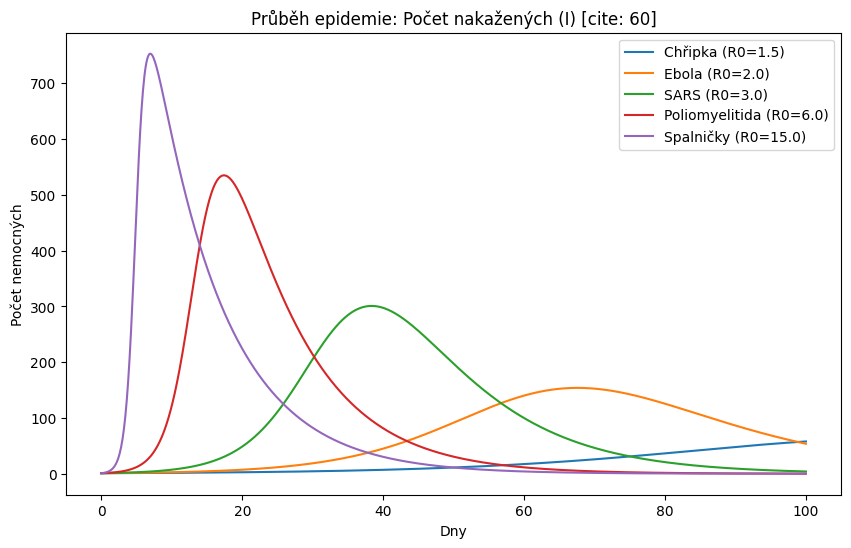

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

N = 1000
y0 = [999, 1, 0]
t = np.linspace(0, 100, 1000)
gamma = 1/10

diseases = {"Chřipka": 1.5, "Ebola": 2.0, "SARS": 3.0, "Poliomyelitida": 6.0, "Spalničky": 15.0}

plt.figure(figsize=(10, 6))
for name, r0 in diseases.items():
    beta = r0 * gamma
    sol = odeint(sir_model, y0, t, args=(N, beta, gamma))
    plt.plot(t, sol[:, 1], label=f'{name} (R0={r0})')

plt.title("Průběh epidemie: Počet nakažených (I) [cite: 60]")
plt.xlabel("Dny"); plt.ylabel("Počet nemocných"); plt.legend(); plt.show()

Otázky:

1.  Kdy dojde k vrcholu epidemie?
    - nastává v závislosti velikosti reprodukčního číla => čím je číslo větší, tím dřiv dojde k vrcholu.

2. Jak dlouho epidemie potrvá?
    - doba epidemie je kratčí u nemocí s větší infekcí => nemoc rychle projde populací

3. Kolik jedinců nakonec onemocní a kolik ne?
    - Finální číslo zasažených lze zjistit z kategorie R, nebo zbytkem jedinců v kategorii S 